# CNN for the Detection of Plant Pathologies

In [1]:
# Intalación de dependencias.
!pip -q install optuna
!pip -q install kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 8.1 MB/s eta 0:00:00


In [ ]:
# Damos acceso al API token de kaggle.
!mkdir -p /root/.config/kaggle
!cp "/content/drive/MyDrive/Redes neuronales/Tarea 6. Identificación de enfermedad de una planta/kaggle.json" /root/.config/kaggle/kaggle.json
!chmod 600 /root/.config/kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c plant-pathology-2020-fgvc7

 99% 770M/779M [00:16<00:00, 125MB/s] 
100% 779M/779M [00:16<00:00, 50.2MB/s]


In [ ]:
# Descomprimimos la base de datos en el drive.
data_dest_folder = "/content/drive/MyDrive/Redes neuronales/Tarea 6. Identificación de enfermedad de una planta/data"
zip_file_path = "/content/plant-pathology-2020-fgvc7.zip"
!mkdir -p "{data_dest_folder}"
!unzip -q "{zip_file_path}" -d "{data_dest_folder}"

In [2]:
# Impotamos librerías a utilizar.
import tensorflow as tf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import wandb
from wandb.integration.keras import WandbCallback
from wandb.integration.keras import WandbMetricsLogger

import optuna

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical, image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

In [3]:
# Importamos los datos del drive de colab.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
wandb.login(key=os.getenv("WANDB_API_KEY"))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: emilio-soto (emilio-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
# Ordenamos los datos.
data_path = "/content/drive/MyDrive/Redes neuronales/Tarea 6. Identificación de enfermedad de una planta/data"
image_dir = f"{data_path}/images"
csv_path = f"{data_path}/train.csv"

# Visualizamos.
df = pd.read_csv(csv_path)
df.head(8)

,image_id,healthy,multiple_diseases,rust,scab
0,Train_0,0,0,0,1
1,Train_1,0,1,0,0
2,Train_2,1,0,0,0
3,Train_3,0,0,1,0
4,Train_4,1,0,0,0
5,Train_5,1,0,0,0
6,Train_6,0,1,0,0
7,Train_7,0,0,0,1


In [7]:
# Convertimos a one hot encoding en una sola columna.
label_columns = ['healthy', 'multiple_diseases', 'rust', 'scab']
df['label'] = df[label_columns].idxmax(axis=1)

In [8]:
# Revisamos las imágenes por clase.
print("Conteo de imágenes por clase:")
print(df['label'].value_counts())

Conteo de imágenes por clase:
label
rust                 622
scab                 592
healthy              516
multiple_diseases     91
Name: count, dtype: int64


In [9]:
# Agregamos la extensión .jpg a las imagenes.
if not df['image_id'].str.contains('.jpg').any():
    print("Añadiendo extensión .jpg a 'image_id'...")
    df['image_id'] = df['image_id'] + '.jpg'
else:
    print("'image_id' ya tiene la extensión .jpg.")

Añadiendo extensión .jpg a 'image_id'...


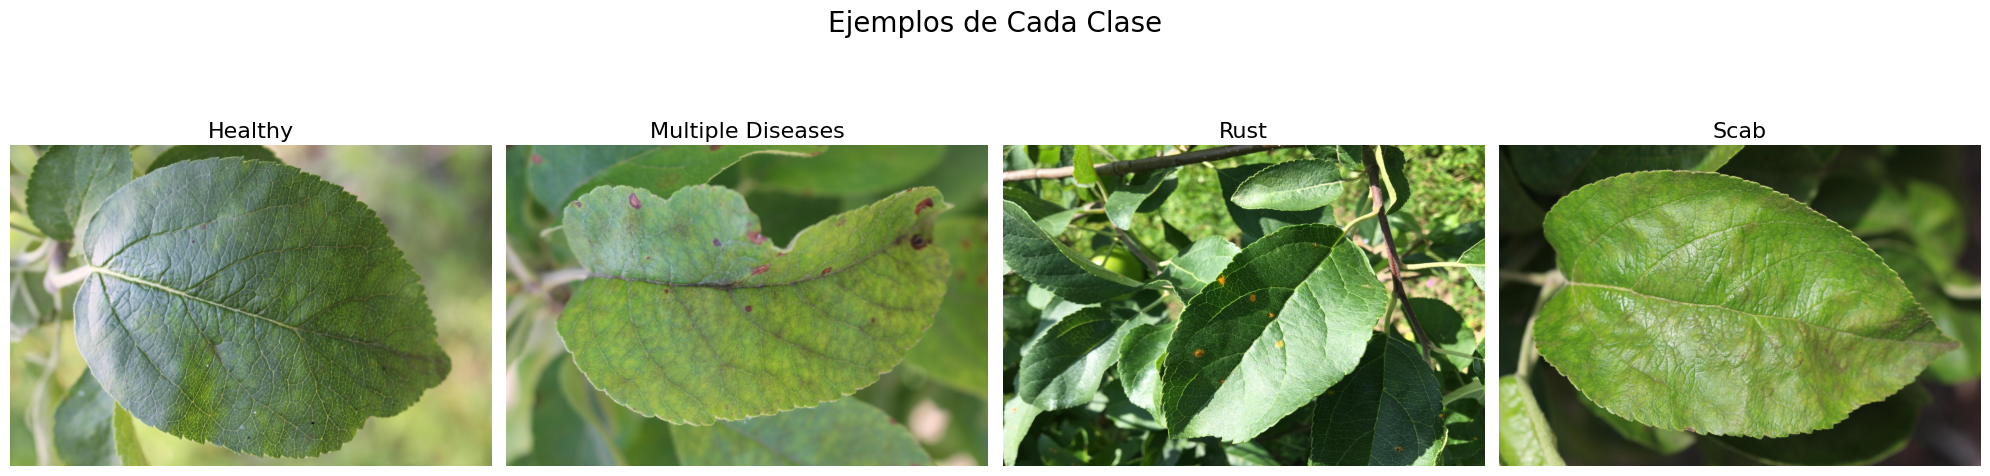

In [10]:
# Guardamos los nombres de una imagen de cada clase.
samples = {}
for label in label_columns:
    img_id = df[df[label] == 1].iloc[2]['image_id']
    samples[label] = img_id

# Graficamos un ejemplo de cada clase.
plt.figure(figsize=(20, 5))

# Para Healthy
plt.subplot(1, 4, 1)
img = load_img(os.path.join(image_dir, samples['healthy']))
plt.imshow(img)
plt.title('Healthy', fontsize=16)
plt.axis('off')

# Para Multiple Diseases
plt.subplot(1, 4, 2)
img = load_img(os.path.join(image_dir, samples['multiple_diseases']))
plt.imshow(img)
plt.title('Multiple Diseases', fontsize=16)
plt.axis('off')

# Para Rust
plt.subplot(1, 4, 3)
img = load_img(os.path.join(image_dir, samples['rust']))
plt.imshow(img)
plt.title('Rust', fontsize=16)
plt.axis('off')

# Para Scab
plt.subplot(1, 4, 4)
img = load_img(os.path.join(image_dir, samples['scab']))
plt.imshow(img)
plt.title('Scab', fontsize=16)
plt.axis('off')

plt.suptitle('Ejemplos de Cada Clase', fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

In [11]:
# División de datos.
# Separamos el test.
main_df, test_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])

# El resto lo separamos entre entrenamiento y validación.
train_df, val_df = train_test_split(main_df, test_size=0.20, random_state=42, stratify=main_df['label'])

In [12]:
# Aumentamos los datos.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Normalizamos los datos de validación y prueba.
val_test_datagen = ImageDataGenerator(rescale=1./255)

IMG_SIZE = (180, 180)
BATCH_SIZE = 32
# Se crean los generadores de imagenes.
train_dataset = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='image_id',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42)

validation_dataset = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir,
    x_col='image_id',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False)

test_dataset = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=image_dir,
    x_col='image_id',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False)

Found 1019 validated image filenames belonging to 4 classes.
Found 255 validated image filenames belonging to 4 classes.
Found 547 validated image filenames belonging to 4 classes.


In [13]:
# Etiquetas del set de entrenamiento.
y_train_labels = train_df['label']

# Calculamos los pesos de forma 'balanced' para que las clases con menos muestras tengan un peso mayor.
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels)

# El 'train_dataset' (generador) nos dice qué índice le puso a cada clase.
class_indices = train_dataset.class_indices
print("Índices de clases:", class_indices)

# Creamos el diccionario final de pesos.
class_weight_dict = {class_indices[label]: weight for label, weight in zip(np.unique(y_train_labels), class_weights)}

print("Pesos calculados para el modelo: \n", class_weight_dict)

Índices de clases: {'healthy': 0, 'multiple_diseases': 1, 'rust': 2, 'scab': 3}
Pesos calculados para el modelo: 
 {0: np.float64(0.8814878892733564), 1: np.float64(4.995098039215686), 2: np.float64(0.7320402298850575), 3: np.float64(0.7696374622356495)}


In [14]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180,180,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
# Congelamos la base.
conv_base.trainable = False

## Pruebas rápida.

In [19]:
# Hacemos una prueba rápida.
_ , mini_train_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df['label'])

_ , mini_val_df = train_test_split(
    val_df,
    test_size=0.1,
    random_state=42,
    stratify=val_df['label'])

print(f"Tamaño del set completo de train: {len(train_df)}")
print(f"Tamaño del mini set de train: {len(mini_train_df)}")
print(f"Clases en el mini set:\n{mini_train_df['label'].value_counts()}")

# Creamos los generadores de la parte reducida de la base de datos.
mini_train_dataset = train_datagen.flow_from_dataframe(
    dataframe=mini_train_df,
    directory=image_dir,
    x_col='image_id',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42)

mini_validation_dataset = val_test_datagen.flow_from_dataframe(
    dataframe=mini_val_df,
    directory=image_dir,
    x_col='image_id',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False)

Tamaño del set completo de train: 1019
Tamaño del MINI-SET de train: 102
Clases en el MINI-SET:
label
rust                 35
scab                 33
healthy              29
multiple_diseases     5
Name: count, dtype: int64
Found 102 validated image filenames belonging to 4 classes.
Found 26 validated image filenames belonging to 4 classes.


In [20]:
# Colocamos clasificador.
x = conv_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

# Ensamblamos el modelo, compilamos y vemos el resumen.
model = Model(inputs=conv_base.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [21]:
# Iniciamos corrida.
wandb.init(project="Plant-Pathology-CNN", name="VGG16_Test_Run")
callbacks_list = [WandbMetricsLogger(),
    EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)]
# Entrenamos.
history = model.fit(
    mini_train_dataset,
    validation_data=mini_validation_dataset,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks_list)

wandb.finish()

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 85s 21s/step - accuracy: 0.2179 - loss: 1.4832 - val_accuracy: 0.1923 - val_loss: 1.4364
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 48s 12s/step - accuracy: 0.3048 - loss: 1.4042 - val_accuracy: 0.2308 - val_loss: 1.4085
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 79s 11s/step - accuracy: 0.2824 - loss: 1.5386 - val_accuracy: 0.3462 - val_loss: 1.3901
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 45s 11s/step - accuracy: 0.2165 - loss: 1.5421 - val_accuracy: 0.3846 - val_loss: 1.3783
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 45s 11s/step - accuracy: 0.3350 - loss: 1.4649 - val_accuracy: 0.4615 - val_loss: 1.3649
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 46s 14s/step - accuracy: 0.3679 - loss: 1.2544 - val_accuracy: 0.4231 - val_loss: 1.3508
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 46s 11s/step - accuracy: 0.2559 - loss: 1.4787 - val_accuracy: 0.4231 - val_loss: 1.3429
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 45s 11s/step - accuracy: 0.2094 - loss: 1.6725 - val_accuracy: 0.4231 - val_loss: 1.3364


epoch/accuracy,▁▇▅▂▇█▂▃▇▇
epoch/epoch,▁▂▃▃▄▅▆▆▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁
epoch/loss,▄▂▅▃▁▁▅█▆▂
epoch/val_accuracy,▁▂▅▆█▇▇▇██
epoch/val_loss,█▆▅▄▃▂▂▂▁▁
epoch/accuracy,0.30392
epoch/epoch,9
epoch/learning_rate,0.0001
epoch/loss,1.4678
epoch/val_accuracy,0.46154


In [29]:
# Este modelo se utilizó para un clasificador de imagenes de virus MNIST.
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(4, activation='softmax')])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 118336)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │    15,147,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,167,044 (57.86 MB)

 Trainable params: 15,167,044 (57.86 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
wandb.init(
    project="Plant-Pathology-CNN",
    name="Prueba_Mini_Virus MNIST_extense")


callbacks_list = [
    WandbMetricsLogger(),
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        verbose=1,
        restore_best_weights=True)]

history = model.fit(
    mini_train_dataset,
    validation_data=mini_validation_dataset,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks_list)

wandb.finish()

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3346 - loss: 1.4341 - val_accuracy: 0.2692 - val_loss: 1.6292
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.2319 - loss: 1.6041 - val_accuracy: 0.2692 - val_loss: 1.8517
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.1913 - loss: 1.8114 - val_accuracy: 0.2692 - val_loss: 1.5482
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.1873 - loss: 1.6528 - val_accuracy: 0.2692 - val_loss: 1.4654
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.3270 - loss: 1.4676 - val_accuracy: 0.3462 - val_loss: 1.3053
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.2125 - loss: 1.7446 - val_accuracy: 0.3462 - val_loss: 1.3290
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.2680 - loss: 1.2883 - val_accuracy: 0.3462 - val_loss: 1.3872
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.1816 - loss: 1.5043 - val_accuracy: 0.4615 - val_loss: 1.3556
Epoch 9/10
4/

epoch/accuracy,█▆▁▃▇▆▅▂▄▅
epoch/epoch,▁▂▃▃▄▅▆▆▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁
epoch/loss,▄█▇▃▃▂▁▂▂▃
epoch/val_accuracy,▁▁▁▁▄▄▄█▁▄
epoch/val_loss,▅█▄▃▁▁▂▂▁▁
epoch/accuracy,0.26471
epoch/epoch,9
epoch/learning_rate,0.0001
epoch/loss,1.4826
epoch/val_accuracy,0.34615


In [26]:
# Modelo propuesto.
model = keras.Sequential([
    layers.Input(shape=(180, 180, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 180, 180, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 90, 90, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 45, 45, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │    15,859,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,148,004 (61.60 MB)

 Trainable params: 16,148,004 (61.60 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
wandb.init(
    project="Plant-Pathology-CNN",
    name="Prueba_Mini_propuesto" )

callbacks_list = [
    WandbMetricsLogger(),
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        verbose=1,
        restore_best_weights=True)]

history = model.fit(
    mini_train_dataset,
    validation_data=mini_validation_dataset,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks_list)

wandb.finish()

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 32s 7s/step - accuracy: 0.3093 - loss: 1.3998 - val_accuracy: 0.3077 - val_loss: 1.2822
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 27s 8s/step - accuracy: 0.2995 - loss: 1.5288 - val_accuracy: 0.3462 - val_loss: 1.3341
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 29s 7s/step - accuracy: 0.2950 - loss: 1.5542 - val_accuracy: 0.3462 - val_loss: 1.3688
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 25s 6s/step - accuracy: 0.2832 - loss: 1.3620 - val_accuracy: 0.3462 - val_loss: 1.3806
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


epoch/accuracy,█▇▃▁
epoch/epoch,▁▃▆█
epoch/learning_rate,▁▁▁▁
epoch/loss,▇█▄▁
epoch/val_accuracy,▁███
epoch/val_loss,▁▅▇█
epoch/accuracy,0.2549
epoch/epoch,3
epoch/learning_rate,0.0001
epoch/loss,1.39544
epoch/val_accuracy,0.34615


## Uso de la red más conveniente.

In [32]:
def build_simple_model(trial):
    # Hiperparámetros que Optuna va a optimizar.
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    dense_units = trial.suggest_int("dense_units", 64, 256)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)

    model = keras.Sequential([
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(180, 180, 3)),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(4, activation='softmax')])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy'])
    return model

In [33]:
def objective(trial):
    keras.backend.clear_session()

    # Construimos el modelo con los parámetros del trial.
    model = build_simple_model(trial)
    # Iniciamos wand.
    run = wandb.init(
        project="Plant-Pathology-CNN",
        name=f"Intento de optuna {trial.number}_Virus_model",
        config=trial.params,
        reinit=True,
        group="Optuna-Simple-CNN")

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=15,
        class_weight=class_weight_dict,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=3, verbose=0),
            WandbMetricsLogger()],
        verbose=0 )
    wandb.finish()
    return history.history['val_loss'][-1]

In [34]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

# Resultados.
print(f"Mejor val_loss: {study.best_value}")
print("Mejores parámetros encontrados:")
print(study.best_params)

[I 2025-11-03 04:07:37,357] A new study created in memory with name: no-name-dc576447-8774-4bc4-a106-c0c3e4e20113
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


epoch/accuracy,▁▂█▁▆
epoch/epoch,▁▃▅▆█
epoch/learning_rate,▁▁▁▁▁
epoch/loss,█▃▃▂▁
epoch/val_accuracy,█▅▄▃▁
epoch/val_loss,▄▁▅▇█
epoch/accuracy,0.35231
epoch/epoch,4
epoch/learning_rate,4e-05
epoch/loss,1.34499
epoch/val_accuracy,0.2


[I 2025-11-03 04:21:27,010] Trial 0 finished with value: 1.401188850402832 and parameters: {'learning_rate': 4.3535322407794875e-05, 'dense_units': 169, 'dropout_rate': 0.18013071470705994}. Best is trial 0 with value: 1.401188850402832.


epoch/accuracy,▁█▆█▄▃
epoch/epoch,▁▂▄▅▇█
epoch/learning_rate,▁▁▁▁▁▁
epoch/loss,█▂▂▁▁▁
epoch/val_accuracy,▇▆█▂▁▄
epoch/val_loss,▆█▁▇▂▂
epoch/accuracy,0.2895
epoch/epoch,5
epoch/learning_rate,0.00026
epoch/loss,1.35831
epoch/val_accuracy,0.32157


[I 2025-11-03 04:29:28,724] Trial 1 finished with value: 1.330831527709961 and parameters: {'learning_rate': 0.0002551422603433974, 'dense_units': 80, 'dropout_rate': 0.1954588653864474}. Best is trial 1 with value: 1.330831527709961.


[W 2025-11-03 04:32:48,629] Trial 2 failed with parameters: {'learning_rate': 0.0008863214740380052, 'dense_units': 156, 'dropout_rate': 0.15195995267460757} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-2144487155.py", line 14, in objective
    history = model.fit(
              ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py", line 377, in fit
    logs = self.train_function(iterator)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py", line 220, in funct

KeyboardInterrupt: 